Navpreet Kloy, Faith Yang

Dataset:https://www.kaggle.com/datasets/faryalrifaz3374/fitness-tracker-dataset-with-daily-health-metrics/data

In [26]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import (
    train_test_split,       # Split data into train/test sets
    cross_val_score         # Cross-validation for robust evaluation
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [27]:
# load dataset
df = pd.read_csv("fitness_tracker.csv")
df.head()

,user_id,date,age,gender,height_cm,weight_kg,steps,calories_burned,sleep_hours,heart_rate_avg,workout_type,workout_duration_minutes,water_intake_liters,stress_level,mood
0,1102,2015-01-01,38,Female,165.5,59.6,2713,372.5,7.8,74,NaN,0,1.09,2,Tired
1,1435,2015-01-02,21,Female,173.4,52.1,1635,245.4,7.8,96,Running,20,2.93,3,Neutral
2,1860,2015-01-03,24,Male,165.7,85.1,16193,900.0,10.0,60,Running,43,2.24,1,Tired
3,1270,2015-01-04,43,Female,170.9,74.8,15633,819.5,6.5,66,Running,62,2.61,1,Happy
4,1106,2015-01-05,29,Female,157.8,75.0,10309,629.3,7.1,75,NaN,0,3.59,2,Neutral


In [28]:
# dataset structure overiew including data types and missing values
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   4000 non-null   int64  
 1   date                      4000 non-null   object 
 2   age                       4000 non-null   int64  
 3   gender                    4000 non-null   object 
 4   height_cm                 4000 non-null   float64
 5   weight_kg                 4000 non-null   float64
 6   steps                     4000 non-null   int64  
 7   calories_burned           4000 non-null   float64
 8   sleep_hours               4000 non-null   float64
 9   heart_rate_avg            4000 non-null   int64  
 10  workout_type              3325 non-null   object 
 11  workout_duration_minutes  4000 non-null   int64  
 12  water_intake_liters       4000 non-null   float64
 13  stress_level              4000 non-null   int64  
 14  mood    

In [29]:
# displays number of missing (NaN) values in each column
df.isna().sum()

,0
user_id,0
date,0
age,0
gender,0
height_cm,0
weight_kg,0
steps,0
calories_burned,0
sleep_hours,0
heart_rate_avg,0


In [30]:
# display all column names in the dataset
print(df.columns.tolist())

['user_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg', 'steps', 'calories_burned', 'sleep_hours', 'heart_rate_avg', 'workout_type', 'workout_duration_minutes', 'water_intake_liters', 'stress_level', 'mood']


In [31]:
# display counts of each workout_type including missing (NaN) values
df['workout_type'].value_counts(dropna=False)

,count
workout_type,
Gym,689
Walking,676
Yoga,675
NaN,675
Cycling,644
Running,641


In [32]:
# replace NaN values with 'None" in workout feature
df['workout_type'] = df['workout_type'].fillna('None')

In [33]:
df.nunique() #check number of unique values in each feature

,0
user_id,970
date,4000
age,42
gender,2
height_cm,453
weight_kg,611
steps,3573
calories_burned,2756
sleep_hours,71
heart_rate_avg,61


In [34]:
# view unique values and value for selected features
cols = ['gender', 'workout_type', 'mood', 'stress_level']

for col in cols:
    print(df[col].value_counts())
    print()

gender
Male      2025
Female    1975
Name: count, dtype: int64

workout_type
Gym        689
Walking    676
Yoga       675
None       675
Cycling    644
Running    641
Name: count, dtype: int64

mood
Happy      1359
Tired      1329
Neutral    1312
Name: count, dtype: int64

stress_level
2     429
1     409
5     405
6     404
9     403
3     396
4     391
10    389
7     388
8     386
Name: count, dtype: int64



In [35]:
# display unique mood values to confirm the target labels
print(df['mood'].unique())

['Tired' 'Neutral' 'Happy']


In [36]:
# statistical summary of numerical features
df.describe()

,user_id,age,height_cm,weight_kg,steps,calories_burned,sleep_hours,heart_rate_avg,workout_duration_minutes,water_intake_liters,stress_level
count,4000.00000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1503.28550,38.463000,169.968275,70.312175,10574.06100,616.689175,6.994475,75.102250,45.258500,2.487563,5.447250
std,292.46269,12.036231,10.013916,14.446759,5432.83169,211.027318,1.462816,9.878522,27.511087,0.706263,2.880589
min,1000.00000,18.000000,150.000000,45.000000,1003.00000,120.000000,3.000000,50.000000,0.000000,0.500000,1.000000
25%,1246.00000,28.000000,163.000000,59.900000,5821.00000,436.200000,6.000000,68.000000,26.000000,2.000000,3.000000
50%,1506.50000,38.000000,169.800000,70.200000,10725.00000,629.800000,7.000000,75.000000,47.000000,2.490000,5.000000
75%,1760.00000,49.000000,176.800000,80.300000,15187.50000,807.825000,8.000000,82.000000,69.000000,2.960000,8.000000
max,1999.00000,59.000000,200.000000,116.600000,19993.00000,900.000000,10.000000,110.000000,89.000000,5.000000,10.000000


In [37]:
# Convert string values to numeric using LabelEncoder

# create an instance of LableEncoder
le = LabelEncoder()

# list of categorical columns to encode
cols = ["gender", "workout_type"]

for col in cols:
    df[col] = le.fit_transform(df[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))    # store mapping for interpretation and user input
    print(col, mapping)                                           # display mapping

df # view encoded categorical features

gender {'Female': np.int64(0), 'Male': np.int64(1)}
workout_type {'Cycling': np.int64(0), 'Gym': np.int64(1), 'None': np.int64(2), 'Running': np.int64(3), 'Walking': np.int64(4), 'Yoga': np.int64(5)}


,user_id,date,age,gender,height_cm,weight_kg,steps,calories_burned,sleep_hours,heart_rate_avg,workout_type,workout_duration_minutes,water_intake_liters,stress_level,mood
0,1102,2015-01-01,38,0,165.5,59.6,2713,372.5,7.8,74,2,0,1.09,2,Tired
1,1435,2015-01-02,21,0,173.4,52.1,1635,245.4,7.8,96,3,20,2.93,3,Neutral
2,1860,2015-01-03,24,1,165.7,85.1,16193,900.0,10.0,60,3,43,2.24,1,Tired
3,1270,2015-01-04,43,0,170.9,74.8,15633,819.5,6.5,66,3,62,2.61,1,Happy
4,1106,2015-01-05,29,0,157.8,75.0,10309,629.3,7.1,75,2,0,3.59,2,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1576,2025-12-09,42,1,162.8,84.9,14767,854.3,8.7,72,1,87,2.72,9,Neutral
3996,1841,2025-12-10,33,0,166.3,84.3,16111,900.0,5.9,66,3,75,2.74,8,Neutral
3997,1852,2025-12-11,32,1,159.5,74.2,8221,487.0,6.0,57,5,37,3.39,3,Neutral
3998,1516,2025-12-12,43,1,177.9,75.8,8814,503.1,5.4,97,5,66,3.05,6,Happy


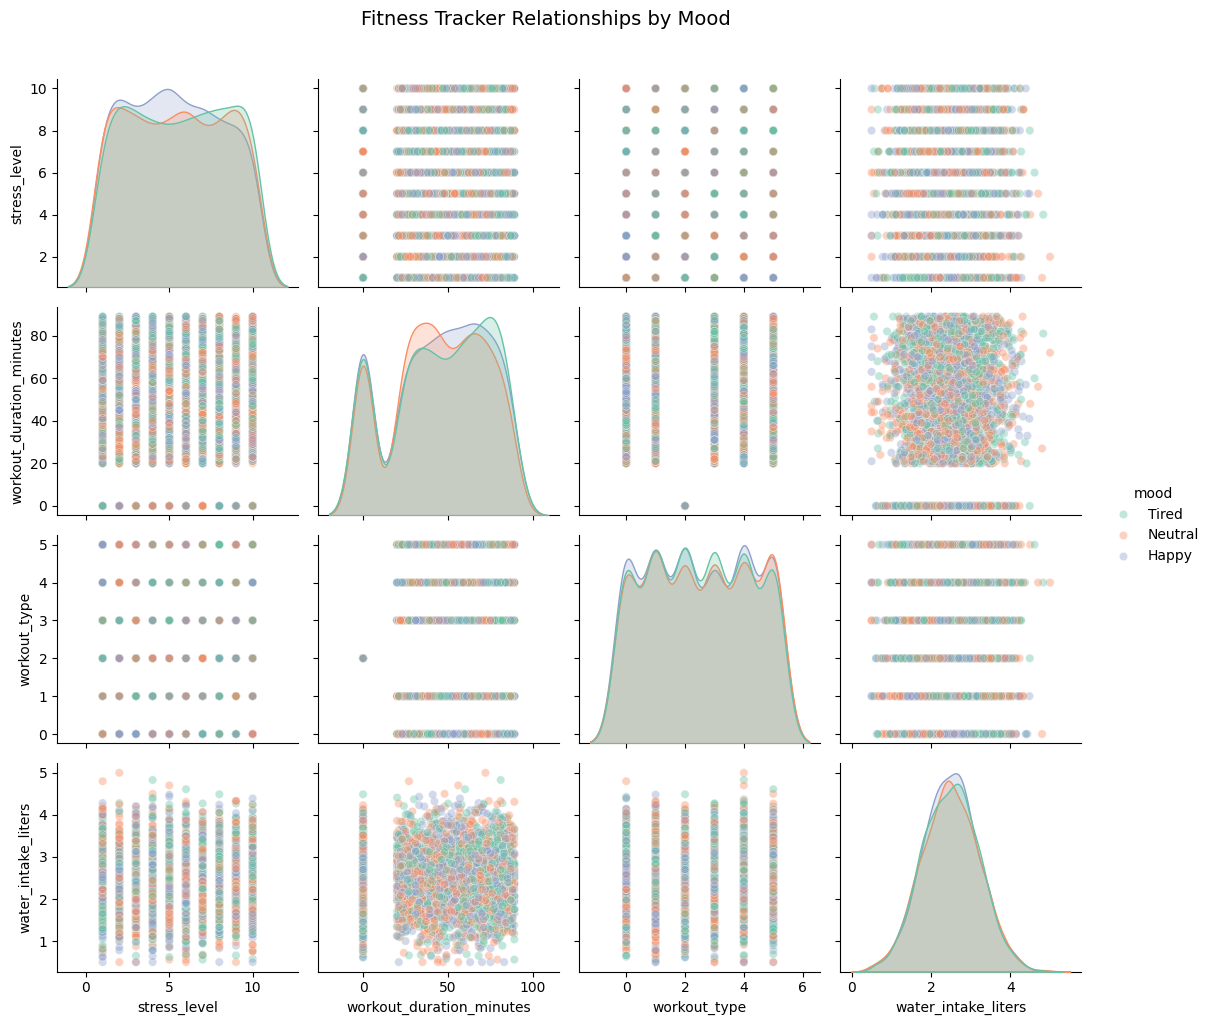

   -> Pair plot saved as 'fitness_pairplot.png'
   -> Look for features where the 2 colors separate well.
      Those features will be most useful for KNN!



In [56]:
# --- Pair Plot ---
# We pick features + the label to keep the plot readable
plot_features = ['stress_level', 'workout_duration_minutes', 'workout_type','water_intake_liters','mood']

g = sns.pairplot(
    df[plot_features],         # Only these columns
    hue='mood',           # Color by mood
    palette='Set2',            # A nice color palette
    diag_kind='kde',           # Diagonal: show density curves instead of histograms
    plot_kws={                 # Settings for the scatter plots
        'alpha': 0.4,          # Semi-transparent dots
        'edgecolor': 'w'       # White edges around dots
    }
)

g._legend.set_bbox_to_anchor((1.1, 0.5))  #  move legend outside the plot area (right side) for better readability


plt.suptitle('Fitness Tracker Relationships by Mood', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('fitness_pairplot.png', dpi=150)
plt.show()

print("   -> Pair plot saved as 'fitness_pairplot.png'")
print("   -> Look for features where the 2 colors separate well.")
print("      Those features will be most useful for KNN!")
print()


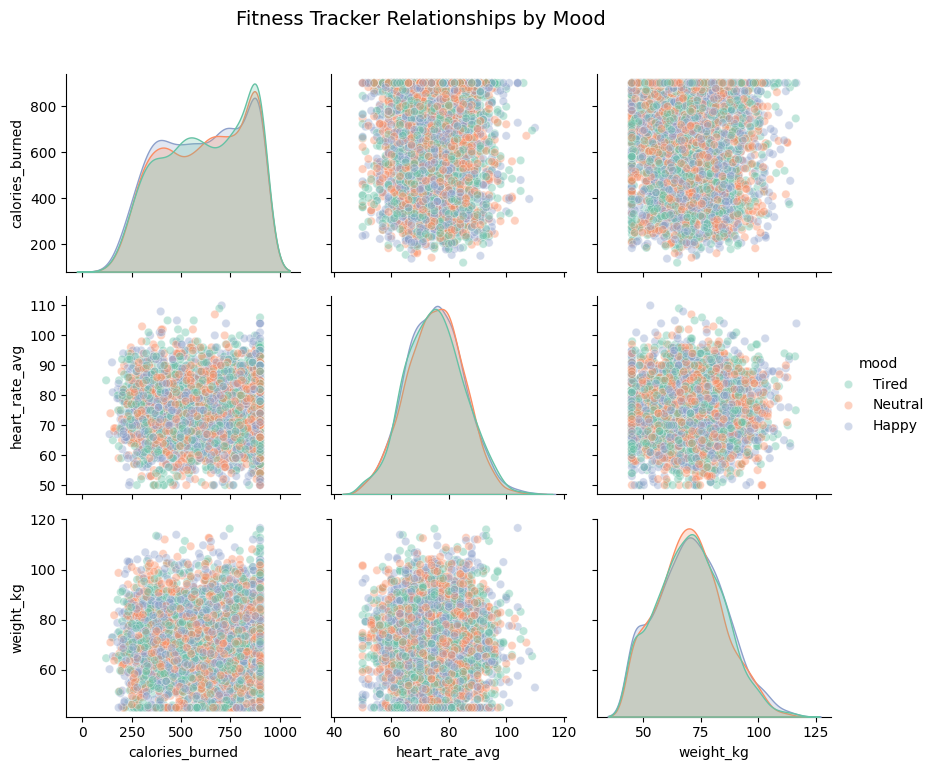

   -> Pair plot saved as 'fitness_pairplot.png'
   -> Look for features where the 2 colors separate well.
      Those features will be most useful for KNN!



In [58]:
 #--- Pair Plot ---
# We pick features + the label to keep the plot readable
plot_features = ['calories_burned', 'heart_rate_avg', 'weight_kg','mood']

g = sns.pairplot(
    df[plot_features],         # Only these columns
    hue='mood',           # Color by mood
    palette='Set2',            # A nice color palette
    diag_kind='kde',           # Diagonal: show density curves instead of histograms
    plot_kws={                 # Settings for the scatter plots
        'alpha': 0.4,          # Semi-transparent dots
        'edgecolor': 'w'       # White edges around dots
    }
)

g._legend.set_bbox_to_anchor((1.1, 0.5))  #  move legend outside the plot area (right side) for better readability


plt.suptitle('Fitness Tracker Relationships by Mood', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('fitness_pairplot2.png', dpi=150)
plt.show()

print("   -> Pair plot saved as 'fitness_pairplot2.png'")
print("   -> Look for features where the 2 colors separate well.")
print("      Those features will be most useful for KNN!")
print()


/tmp/ipykernel_13335/3315438450.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


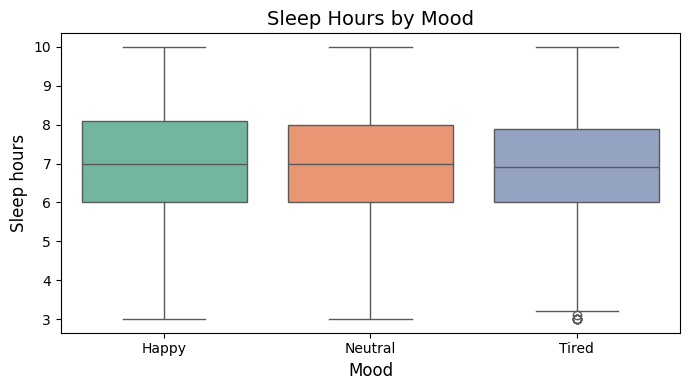

   -> Box plot saved as 'mood_boxplot.png'



In [50]:

# --- Individual feature comparison ---
# Let's also make a box plot for fitness features by mood
# Box plots show the median, quartiles, and outliers
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x='mood',             # Categories on x-axis
    y='sleep_hours',          # Values on y-axis
    palette='Set2',            # Same colors as pair plot
    order=['Happy', 'Neutral', 'Tired']  # Force this order
)
plt.xlabel('Mood', fontsize=12)
plt.ylabel('Sleep hours', fontsize=12)
plt.title('Sleep Hours by Mood', fontsize=14)
plt.tight_layout()
plt.savefig('mood_boxplot.png', dpi=150)
plt.show()

print("   -> Box plot saved as 'mood_boxplot.png'")
print()

/tmp/ipykernel_13335/609344932.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


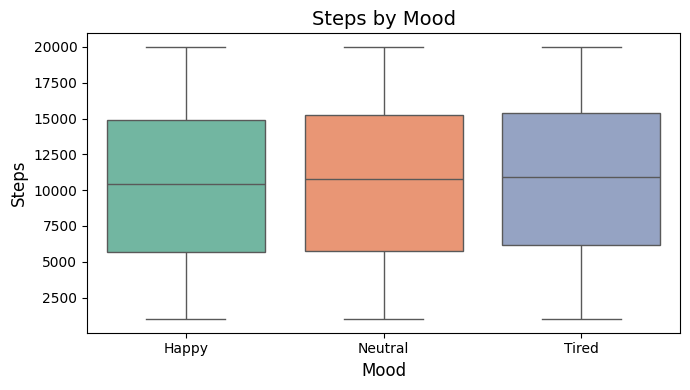

   -> Box plot saved as 'mood_boxplot2.png'



In [60]:

# --- Individual feature comparison ---
# Let's also make a box plot for fitness features by mood
# Box plots show the median, quartiles, and outliers
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x='mood',             # Categories on x-axis
    y='steps',          # Values on y-axis
    palette='Set2',            # Same colors as pair plot
    order=['Happy', 'Neutral', 'Tired']  # Force this order
)
plt.xlabel('Mood', fontsize=12)
plt.ylabel('Steps', fontsize=12)
plt.title('Steps by Mood', fontsize=14)
plt.tight_layout()
plt.savefig('mood_boxplot2.png', dpi=150)
plt.show()

print("   -> Box plot saved as 'mood_boxplot2.png'")
print()

In [40]:
# Separate features from labels
X = df.drop(['user_id', 'date','mood'],axis=1)    # Select columns except the label and columns dropped
y = df['mood']                 # Just the label column

In [41]:
# Split: 80% training, 20% testing
# stratify=y ensures each age group is proportionally represented in both the training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")    # number of training samples
print(f"Testing samples:  {X_test.shape[0]}")     # number of testing samples
print()

# Verify the class balance in both sets
print("Class balance check:")
print(f"Training: {dict(pd.Series(y_train).value_counts())}")
print(f"Testing: {dict(pd.Series(y_test).value_counts())}")
print("  (Should be roughly proportional)")
print()

Training samples: 3200
Testing samples:  800

Class balance check:
Training: {'Happy': np.int64(1087), 'Tired': np.int64(1063), 'Neutral': np.int64(1050)}
Testing: {'Happy': np.int64(272), 'Tired': np.int64(266), 'Neutral': np.int64(262)}
  (Should be roughly proportional)



In [42]:
# Scale features using fit_transform on training and transform on testing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Learn + scale
X_test_scaled  = scaler.transform(X_test)         # Scale only (no learning)

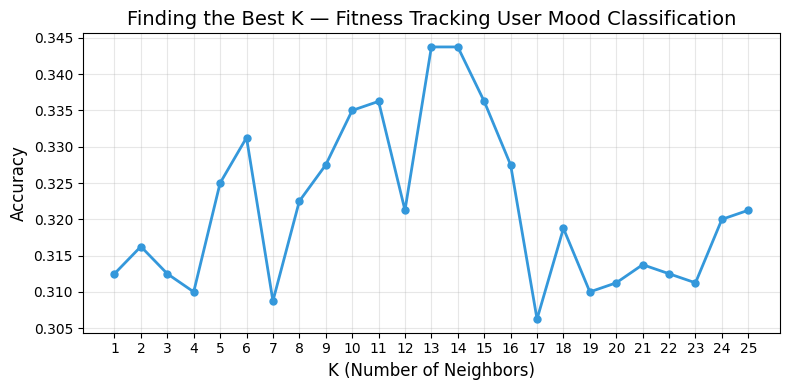

   -> Best K = 13
   -> Best Accuracy = 34.38%
   -> Chart saved as 'mood_best_k.png'



In [43]:
# Find the best value of K for the KNN model, testing every K from 1-25

# Test K values from 1 to 25
k_values = range(1, 26)
accuracies = []  # Create list to store each K's accuracy

# New KNN model is created and trained for each value of K
# Accuracy for each model is stored in the accuracies list
for k in k_values:
    # Create a new model with this K
    model = KNeighborsClassifier(n_neighbors=k)

    # Train it on the same training data
    model.fit(X_train_scaled, y_train)

    # Predict on the test data
    pred = model.predict(X_test_scaled)

    # Calculate accuracy and save it
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

# Plot K vs Accuracy to visualize the performance for each K
plt.figure(figsize=(8, 4))
plt.plot(
    k_values,           # x-axis: K values
    accuracies,         # y-axis: accuracy for each K
    marker='o',         # Circle marker at each point
    color='#3498db',    # Blue color
    linewidth=2,        # Line thickness
    markersize=5        # Marker size
)
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Finding the Best K — Fitness Tracking User Mood Classification', fontsize=14)
plt.xticks(k_values)      # Show every K value on x-axis
plt.grid(alpha=0.3)        # Faint grid lines for readability
plt.tight_layout()
plt.savefig('mood_best_k.png', dpi=150)
plt.show()

# Find the K with the highest accuracy
best_k = list(k_values)[np.argmax(accuracies)]  # np.argmax returns the INDEX of the maximum value in accuraciesß list, which maps to the corresponding K value in k_values list
best_accuracy = max(accuracies) # gets and stores the highest accuracy value

print(f"   -> Best K = {best_k}")
print(f"   -> Best Accuracy = {best_accuracy:.2%}")
print(f"   -> Chart saved as 'mood_best_k.png'")
print()

In [59]:
# Build and train the KNN model

# Create a KNN classifier with selected K value
knn = KNeighborsClassifier(n_neighbors=13)

# Train the model on the training data using .fit
knn.fit(X_train_scaled, y_train)

print("Model trained with K=13 neighbors.")
print()

# Make predictions on the test set
# For each test sample, KNN:
#   1. Calculates distance to ALL training samples
#   2. Finds the 3 closest ones
#   3. Takes a majority vote among those 3
y_pred = knn.predict(X_test_scaled)
print("Predictions made on the test set.")

Model trained with K=13 neighbors.

Predictions made on the test set.


Overall Accuracy: 34.38%
Detailed Classification Report:
              precision    recall  f1-score   support

       Happy       0.34      0.39      0.36       272
     Neutral       0.33      0.31      0.32       262
       Tired       0.36      0.33      0.34       266

    accuracy                           0.34       800
   macro avg       0.34      0.34      0.34       800
weighted avg       0.34      0.34      0.34       800



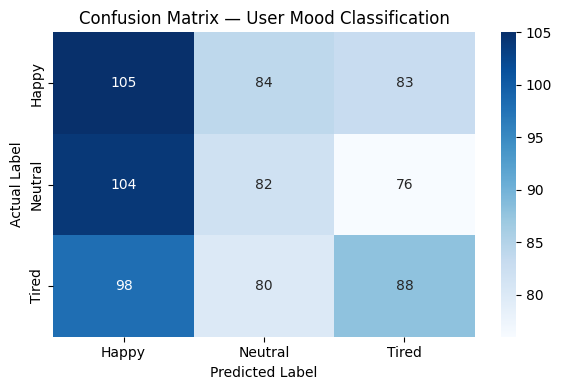

   -> Confusion matrix saved as 'mood_confusion.png'



In [48]:
# Evaluation of KNN model

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")

# Detailed classification report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# Displays the following:
#   precision = of all moods that were classfied, how many really were?
#   recall    = for each mood class, how many of each did we catch?
#   f1-score  = the harmonic mean of precision and recall
#   support   = how many actual samples of each class were in the test set


# --- Confusion Matrix Heatmap ---
# This visual makes it easy to see where the model gets confused
cm = confusion_matrix(
    y_test, y_pred,
    labels=['Happy', 'Neutral', 'Tired']  # Force this order in the matrix
)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,                                        # The confusion matrix data
    annot=True,                                # Show numbers inside cells
    fmt='d',                                   # Format as integers (not decimals)
    cmap='Blues',                               # Blue color scheme
    xticklabels=['Happy', 'Neutral', 'Tired'],       # Labels for predicted (x-axis)
    yticklabels=['Happy', 'Neutral', 'Tired']        # Labels for actual (y-axis)
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix — User Mood Classification')
plt.tight_layout()
plt.savefig('mood_confusion.png', dpi=150)
plt.show()

print("   -> Confusion matrix saved as 'mood_confusion.png'")
print()

In [49]:
# Prepare a provision for a new data entry and its prediction of an outcome.

def predict_mood():
    while True:
        try:
            age = int(input("Enter age: "))
            gender = int(input("Enter gender (Female: 0 or Male: 1): "))
            height_cm = float(input("Enter height of user in centimeters: "))
            weight_kg = float(input("Enter weight in kg: "))
            steps = int(input("Enter total number of steps walked by the user during the day: "))
            calories_burned = float(input("Enter estimated number of calories burned during daily physical activity: "))
            sleep_hours = float(input("Enter total hours of sleep recorded during the day.: "))
            heart_rate_avg = int(input("Enter average heart rate of the user during the day, measured in beats per minute (BPM): "))
            workout_type = int(input("Enter workout type (Cycling: 0, Gym: 1, None: 2, Running: 3, Walking: 4, Yoga: 5): "))
            workout_duration_minutes = int(input("Enter workout duration in minutes: "))
            water_intake_liters = float(input("Enter water intake in liters: "))
            stress_level = int(input("Enter stress level between 1-10: "))


            # input validation for non-negative values
            if any(val < 0 for val in [age, height_cm, weight_kg, steps, calories_burned, sleep_hours, heart_rate_avg, workout_duration_minutes, water_intake_liters]):
              print("Error: Please enter non-negative value.")
              continue  #restart the loop

            # input validation for binary variables
            if any(val not in [0,1] for val in [gender]):
              print("Error: Please enter 0 or 1.")
              continue  #restart the loop

            # input validation for encoded workout type values (0–5)
            if workout_type not in [0,1,2,3,4,5]:
              print("Error: Please enter corresponding values between 0 and 5 for workout type.")
              continue  #restart the loop

             # input validation for encoded stress level values (1–10)
            if stress_level not in [1,2,3,4,5,6,7,8,9,10]:
              print("Error: Please enter corresponding values between 1 and 10 for stress level.")
              continue  #restart the loop


            # create new user dataframe from user input
            new_user_data = pd.DataFrame([[age, gender, height_cm, weight_kg, steps, calories_burned, sleep_hours, heart_rate_avg, workout_type, workout_duration_minutes, water_intake_liters, stress_level]],
                                           columns=['age', 'gender', 'height_cm', 'weight_kg', 'steps', 'calories_burned', 'sleep_hours', 'heart_rate_avg', 'workout_type', 'workout_duration_minutes', 'water_intake_liters', 'stress_level'])

            # Scale the new user data using the SAME scaler from training
            new_user_data_scaled = scaler.transform(new_user_data)

            # Make prediction
            prediction =knn.predict(new_user_data_scaled)[0]


            # print results
            print(f"Prediction Result: '{prediction}' mood")

            if prediction == 'Happy':
                print("Prediction: User is likely to be in a Happy mood.")
            elif prediction == 'Neutral':
                print("Prediction: User is likely to be in a Sad mood.")
            else:
                print("Prediction: User is likely to be in a Tired mood.")


            another_user = input("Enter data for another user? (yes/no): ")
            if another_user.lower() != 'yes':
                break #exit loop
        except ValueError:
            print("Invalid input. Please enter valid numerical values.")

predict_mood()

Enter age: 44
Enter gender (Female: 0 or Male: 1): 0
Enter height of user in centimeters: 170
Enter weight in kg: 50
Enter total number of steps walked by the user during the day.: 6000
Enter estimated number of calories burned during daily physical activity: 400.5
Enter total hours of sleep recorded during the day.: 6.6
Enter average heart rate of the user during the day, measured in beats per minute (BPM): 90
Enter workout type (Cycling: 0, Gym: 1, None: 2, Running: 3, Walking: 4, Yoga: 5): 0
Enter workout duration in minutes: 80
Enter water intake in liters: 1.22
Enter stress level between 1-10: 5
Prediction Result: 'Tired' mood
Prediction: User is likely to be in a Tired mood.
Enter data for another user? (yes/no): no


The Fitness Tracker dataset was used to build a KNN model to predict the user mood. This dataset represented synthetic fitness tracker data simulating the various metrics fitness trackers data may track about its users. There were 3 possible user moods: “Happy”, “Neutral”, and “Tired.” The user mood was predicted using demographic information (age and gender), body measurements (height and weight), user health metrics (stress levels) and activity metrics (workout type, duration, and steps) the dataset provided. During data exploration, it was noted the various features did not form distinct groupings by mood. The data features were plotted using pair plot and box plots to determine distinct groupings of mood.All three mood categories showed significant overlapping, sharing a similar range of value across the various user metrics. Even features that might be expected to vary such as sleep hours or stress levels, showed similar distributions and range across the three mood classifications.The boxplot for Sleep Hours by Mood the median sleep duration was 7 across the mood categories, meaning mood groups have similar sleep hours. Data was then processed and a KNN model was built. The metrics for the model evaluation shows it was not a strong model. It had an accuracy of 34.38%, and the weighted average across the moods were 0.34 across for precision, recall , and F1-score metrics. This means the model across all the three mood categories had poor performance. Overall, the model was frequently incorrect in its predictions each time and failed to identify actual cases of all the moods.
